# FIP 00 — Fiber photometry exploration with motion energy

Access and plot fiber-photometry (FIP) data, then relate the signals to gross movement
(motion energy). 

- motion energy repo: https://github.com/AllenNeuralDynamics/aind-motion-energy

- ME capsule: https://codeocean.allenneuraldynamics.org/capsule/5856343/tree

- ME batch dispatcher: https://codeocean.allenneuraldynamics.org/capsule/5110154/tree

- Fiber data asset ID: `6babbf3d-6970-4456-aab5-d730ed57c269` (saved parquet hierarchy from
  `save_nwb_list`, loaded with `rachel_analysis_utils.nwb_utils.load_nwb_list`).

**Signal layout:** each row of `df_fip` is one `event` series named `{channel}_{fiber}`
(+ a processed `*_dff` variant). Channels: `G` (green/GCaMP), `R` (red), `Iso` (isosbestic
control); fibers `0`–`4`. `timestamps` are zeroed at the first go cue.

**Flow:** imports → data loading → data processing → data visualization.


## Imports & setup

In [104]:
import os
import glob
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter1d

# Rachel's lab utilities (installed / mounted in the Code Ocean capsule).
from rachel_analysis_utils import nwb_utils as r_utils

# AIND event-alignment primitive (peri-event windowing). df_fip['timestamps'] and the
# df_trials '*_in_session' columns share one clock: t=0 is the first go cue of the session.
from aind_dynamic_foraging_data_utils import alignment

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 4)

In [105]:
# load_nwb_list reads the parquet hierarchy with pd.read_parquet(..., engine="fastparquet"),
# which is hardcoded in rachel_analysis_utils. The capsule image doesn't ship fastparquet,
# so install it on first run. (No-op once it's importable.) For a permanent fix, add
# `fastparquet` to the Code Ocean environment instead.
try:
    import fastparquet  # noqa: F401
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "fastparquet"])
    import fastparquet  # noqa: F401
print("fastparquet", fastparquet.__version__)

fastparquet 2024.11.0


## Data loading

`load_nwb_list(plot_loc)` reads a saved parquet hierarchy laid out as
`plot_loc/<subject>/<session>/df_fip.parquet` and returns one `dummy_nwb` per session (each
with `.df_fip`, `.df_trials`, `.df_events`, `.session_id`). Project data is at
`/root/capsule/data/DA_NE_4channels/` (212 sessions); set `RELOCATE=True` to rediscover the
root by glob if the asset layout changes.


In [106]:
# Hardwired to the attached asset's saved parquet hierarchy so we skip the
# recursive glob every session. This is the `plot_loc` root that load_nwb_list
# wants: plot_loc/<subject>/<session>/df_fip.parquet
plot_loc = "/root/capsule/data/DA_NE_4channels/"

assert os.path.isdir(plot_loc), (
    f"{plot_loc} not found. Attach asset 6babbf3d-6970-4456-aab5-d730ed57c269 "
    "(saved parquet hierarchy) to this capsule, or fix the path."
)
print("plot_loc =", plot_loc)

# Fallback: if the layout ever changes, set RELOCATE=True to rediscover by glob.
RELOCATE = False
if RELOCATE:
    fip_files = glob.glob(os.path.join("/root/capsule/data", "**", "df_fip.parquet"), recursive=True)
    plot_locs = sorted({os.path.dirname(os.path.dirname(os.path.dirname(f))) for f in fip_files})
    print(f"{len(fip_files)} session(s) found across {len(plot_locs)} root(s):", plot_locs)

plot_loc = /root/capsule/data/DA_NE_4channels/


In [ ]:
nwb_list_raw, df_sess, df_slope = r_utils.load_nwb_list(plot_loc, load_fip=True)

print(f"Loaded {len(nwb_list_raw)} session(s):")
for nwb in nwb_list_raw:
    has_fip = getattr(nwb, "df_fip", None) is not None
    print(f"  {nwb.session_id:<32s} fip={has_fip}")

### Curation

`apply_curation_nwb_list` maps each fiber to its brain region (annotating
`df_fip['intended_measurement']`), renames `df_trials` columns, and drops bad
channels/sessions. Set `USE_CURATION=False` to skip it and label traces by fiber number only.

⚠️ `CURATION_FILE` must match THIS dataset's fiber layout. For DA_NE_4channel use
`..._firstpass` — it carries the `correct_mapping` fiber→region dict. (`..._secondpass` lacks
`correct_mapping`, so `intended_measurement` would come back empty.)


In [108]:
USE_CURATION = True
CURATION_FILE = "DA_NE_4channel_datacuration_firstpass"

if USE_CURATION:
    # Locate the curation JSON inside the installed rachel package, with a /src fallback.
    json_path = None
    try:
        import rachel_analysis_utils
        pkg_dir = os.path.dirname(rachel_analysis_utils.__file__)
        cand = os.path.join(pkg_dir, "data_curation", CURATION_FILE + ".json")
        if os.path.exists(cand):
            json_path = cand
    except Exception:
        pass
    if json_path is None:
        hits = glob.glob("/src/**/data_curation/" + CURATION_FILE + ".json", recursive=True)
        assert hits, "Could not locate " + CURATION_FILE + ".json"
        json_path = hits[0]

    with open(json_path, "r") as fh:
        df_curation = json.load(fh)
    print("Using curation:", json_path)

    nwb_list, nwb_list_curated = r_utils.apply_curation_nwb_list(
        nwb_list_raw, df_curation, drop_borderline=True
    )
    print(f"Curated -> {len(nwb_list)} session(s) kept.")
else:
    nwb_list = nwb_list_raw
    print("No curation applied; using raw nwb_list.")

Using curation: /src/rachel-analysis-utils/src/rachel_analysis_utils/data_curation/DA_NE_4channel_datacuration_firstpass.json
Curated -> 172 session(s) kept.


## Data processing

Everything below works on **one session** (`SESSION_IDX`) and produces the objects the plots
consume: the signal table `meta`, the reusable alignment helpers, the three example signals,
and motion energy on the FIP clock.


### Select a session and build the signal table

`df_fip` is tidy: each `event` (`{channel}_{fiber}[_variant]`) is one trace, `timestamps`
zeroed at the first go cue. We drop `pearsonR` series (signal-signal correlations, not
photometry) and, after curation, attach region labels in `meta['region']`.


In [109]:
SESSION_IDX = 0
nwb = nwb_list[SESSION_IDX]
df_fip = nwb.df_fip
# Assert (don't sort) that each series is already time-ordered, so get_trace slices and
# np.interp downstream are valid. Fails loudly if upstream ever delivers unsorted rows.
assert (df_fip.groupby("event")["timestamps"].diff().dropna() >= 0).all(), \
    "df_fip timestamps not sorted within an event — sort before use"
df_trials = getattr(nwb, "df_trials", None)

# Go-cue times on the df_fip clock (first-go-cue-zeroed) drive every peri-event alignment.
ALIGN_COL = "goCue_start_time_in_session"
assert df_trials is not None and ALIGN_COL in df_trials.columns, (
    f"Need '{ALIGN_COL}' on df_trials (first-go-cue-zeroed clock). Available: "
    f"{None if df_trials is None else list(df_trials.columns)}")
cue_col = ALIGN_COL
go_cues = df_trials[ALIGN_COL].dropna().to_numpy()

print("session_id:", nwb.session_id, "| df_fip", df_fip.shape, "| trials", df_trials.shape)

session_id: 808054_2025-09-02 | df_fip (629134, 11) | trials (524, 113)


In [110]:
def parse_event(name):
    """'G_1_dff-poly' -> ('G','1','dff-poly'); 'R_0' -> ('R','0','raw')."""
    parts = name.split("_")
    channel = parts[0]
    fiber = parts[1] if len(parts) > 1 else "?"
    variant = "_".join(parts[2:]) if len(parts) > 2 else "raw"
    return channel, fiber, variant


def get_trace(df_fip, event_name):
    """(t, y) arrays for one FIP series (df_fip is asserted time-sorted per event)."""
    sub = df_fip[df_fip["event"] == event_name]
    return sub["timestamps"].to_numpy(), sub["data"].to_numpy()


# Drop 'pearsonR' series: signal-signal correlations, not photometry.
events = [e for e in sorted(df_fip["event"].unique()) if "pearson" not in e.lower()]
meta = pd.DataFrame([(e,) + parse_event(e) for e in events],
                    columns=["event", "channel", "fiber", "variant"])
if "intended_measurement" in df_fip.columns:  # curation -> region labels
    ev2region = (df_fip.dropna(subset=["intended_measurement"])
                 .groupby("event")["intended_measurement"]
                 .agg(lambda s: s.mode().iloc[0] if not s.mode().empty else None))
    meta["region"] = meta["event"].map(ev2region)
print(f"{len(events)} FIP series (pearsonR excluded)")
meta

5 FIP series (pearsonR excluded)


,event,channel,fiber,variant,region
0,G_0_dff-bright_mc-iso-IRLS,G,0,dff-bright_mc-iso-IRLS,NAc(L)-dLight
1,G_2_dff-bright_mc-iso-IRLS,G,2,dff-bright_mc-iso-IRLS,PL(R)-Gcamp
2,G_3_dff-bright_mc-iso-IRLS,G,3,dff-bright_mc-iso-IRLS,NAc(R)-dLight
3,R_2_dff-bright_mc-iso-IRLS,R,2,dff-bright_mc-iso-IRLS,NAc(R)-rAch
4,R_3_dff-bright_mc-iso-IRLS,R,3,dff-bright_mc-iso-IRLS,NAc(L)-rAch


### Helpers — alignment, z-scoring, cross-correlation

`peri_event(t, y, event_times)` aligns any signal — a FIP trace from `get_trace`, or motion
energy — to event times via the AIND ETR primitive (interpolates each snippet onto a common
grid; `censor=True` blanks samples that spill past the next event). Event times must be on the
df_fip clock — a `*_in_session` column, never `_in_trial` or the raw absolute clock.

In [111]:
def peri_event(t, y, event_times, t_before=1.0, t_after=3.0, fs=20, censor=True):
    """Align signal (t, y) to event_times via the AIND ETR primitive.

    Returns a tidy DataFrame [time, event_number, event_time, data], ready to
    groupby('time'). `censor=True` blanks samples spilling past the next event (use for
    go cues); pass censor=False for closely-spaced events (movement onsets).
    """
    s = pd.DataFrame({"timestamps": np.asarray(t, float),
                      "data": np.asarray(y, float)}).dropna()
    return alignment.event_triggered_response(
        data=s, t="timestamps", y="data",
        event_times=np.asarray(event_times, float),
        t_before=t_before, t_after=t_after,
        output_sampling_rate=fs, output_format="tidy", censor=censor)


def zscore(y):
    """Z-score a 1D array, ignoring NaNs."""
    y = np.asarray(y, float)
    sd = np.nanstd(y)
    return (y - np.nanmean(y)) / sd if sd > 0 else y - np.nanmean(y)


def threshold_onsets(t, y, z_thresh=2.5, refractory=0.5, smooth=5):
    """Upward threshold crossings of a z-scored (optionally smoothed) trace.

    Returns the times (in t's units) where the signal first rises above `z_thresh` SD,
    with a `refractory` (s) dead-time so one bout is counted once.
    """
    y = np.asarray(y, float)
    if smooth and smooth > 1:
        y = uniform_filter1d(np.nan_to_num(y, nan=float(np.nanmedian(y))), size=smooth)
    z = zscore(y)
    above = z > z_thresh
    idx = np.where((~above[:-1]) & above[1:])[0] + 1
    times = np.asarray(t, float)[idx]
    if len(times):  # enforce refractory period
        times = times[np.insert(np.diff(times) > refractory, 0, True)]
    return times


def norm_xcorr(a, b, fs, maxlag=3.0):
    """Normalised cross-correlation of two equal-length, uniformly-sampled signals.

    out[lag] = mean( a[t+lag] * b[t] ) with a, b z-scored. A peak at POSITIVE lag means
    b LEADS a (b precedes a by `lag` seconds).
    """
    a, b = zscore(a), zscore(b)
    n = len(a)
    K = int(round(maxlag * fs))
    lags = np.arange(-K, K + 1)
    out = np.empty(len(lags), float)
    for i, L in enumerate(lags):
        if L >= 0:
            out[i] = np.nanmean(a[L:] * b[:n - L])
        else:
            out[i] = np.nanmean(a[:n + L] * b[-L:])
    return lags / float(fs), out

### Example signals

Pick one representative series per signal type and carry them through every plot:
**NAc DA** (dLight, green), **PL** (GCaMP, green), **NAc ACh** (rAch, red). `pick_example`
matches the region label, prefers a `dff` variant, and breaks ties by most finite samples.
Requires curation (so `meta['region']` exists).


In [112]:
def pick_example(meta, df_fip, region_substr, prefer_variant="dff"):
    """Choose one df_fip 'event' whose region label matches `region_substr`.

    Prefers a dff variant, then the series with the most finite samples.
    """
    if "region" not in meta.columns or meta["region"].dropna().empty:
        raise RuntimeError(
            "No region labels on `meta` -- set USE_CURATION=True (section 3) with the "
            "DA_NE_4channel curation so df_fip carries intended_measurement.")
    cand = meta[meta["region"].fillna("").str.contains(region_substr, case=False)]
    if cand.empty:
        raise ValueError("No FIP series with region matching %r. Have: %s"
                         % (region_substr, sorted(meta["region"].dropna().unique())))
    pref = cand[cand["variant"].str.contains(prefer_variant, case=False)]
    pool = pref if not pref.empty else cand
    best = max(pool["event"], key=lambda ev: int(np.isfinite(get_trace(df_fip, ev)[1]).sum()))
    row = pool[pool["event"] == best].iloc[0]
    return {"event": best, "region": row["region"], "channel": row["channel"],
            "variant": row["variant"]}


# (region substring, plot colour) for each example signal type.
EXAMPLE_SPECS = [
    ("NAc DA (dLight)", "dLight", "#2ca02c"),
    ("PL (GCaMP)",      "Gcamp",  "#1f77b4"),
    ("NAc ACh (rAch)",  "rAch",   "#d62728"),
]

examples = []
for label, substr, color in EXAMPLE_SPECS:
    info = pick_example(meta, df_fip, substr)
    info["label"], info["color"] = label, color
    examples.append(info)

pd.DataFrame(examples)[["label", "event", "channel", "region", "variant", "color"]]

,label,event,channel,region,variant,color
0,NAc DA (dLight),G_0_dff-bright_mc-iso-IRLS,G,NAc(L)-dLight,dff-bright_mc-iso-IRLS,#2ca02c
1,PL (GCaMP),G_2_dff-bright_mc-iso-IRLS,G,PL(R)-Gcamp,dff-bright_mc-iso-IRLS,#1f77b4
2,NAc ACh (rAch),R_2_dff-bright_mc-iso-IRLS,R,NAc(R)-rAch,dff-bright_mc-iso-IRLS,#d62728


### Motion energy on the FIP clock

`aind-motion-energy` gives one value per video frame (1-to-1 with the camera CSV). Each frame
has an absolute `Behav_Time`; subtracting the first go cue puts it on the same
first-go-cue-zeroed clock as `df_fip['timestamps']` (`session_time = Behav_Time − first_go_cue`),
routed through the `video_alignment` helpers. Attach the behavior-video and motion-energy
assets alongside the parquet asset.

*Frame count:* `aind-motion-energy` returns one fewer value than frames (a consecutive-frame difference, with no value for frame 0), so we pad a leading 0 to make it 1-to-1 with the camera CSV. The pad is gated on the ME metadata (`n_me_frames` vs `n_frames_decoded`) and auto-disables if the library is later fixed to pad upstream.


In [113]:
# --- 8a. Locate the behavior-video + motion-energy assets for THIS session ---
# Both are matched by subject_date; the behavior folders carry an acquisition-time
# suffix (e.g. behavior_808054_2025-09-02_10-38-37), so we glob.
subject, date = nwb.session_id.split("_")[:2]

beh_dirs = [d for d in sorted(glob.glob(f"/root/capsule/data/behavior_{subject}_{date}_*"))
            if "motionenergy" not in d]
assert beh_dirs, f"No behavior-video asset for {subject}_{date} under /root/capsule/data"
video_csv = os.path.join(beh_dirs[0], "behavior-videos", "bottom_camera.csv")
assert os.path.exists(video_csv), f"missing {video_csv}"

me_dirs = sorted(glob.glob(f"/root/capsule/data/behavior_{subject}_{date}_*motionenergy*"))
assert me_dirs, f"No motion-energy asset for {subject}_{date}"
hits = glob.glob(os.path.join(me_dirs[0], "**", "bottom_camera_motion_energy_clean.npy"),
                 recursive=True)
assert hits, f"bottom_camera_motion_energy_clean.npy not found under {me_dirs[0]}"
me_path = hits[0]

print("video_csv:", video_csv)
print("me_path:  ", me_path)

video_csv: /root/capsule/data/behavior_808054_2025-09-02_10-38-37/behavior-videos/bottom_camera.csv
me_path:   /root/capsule/data/behavior_808054_2025-09-02_10-38-37_motionenergy_2026-06-29_11-56-53/bottom_camera_motion_energy_clean.npy


In [114]:
# --- 8b. Put motion energy on the first-go-cue-zeroed session clock (the df_fip axis) ---
# The package is editable-installed under /src but checked out on `main`, which lacks
# video_alignment.py (it's on the `video_alignment` branch). Editable installs track the
# working tree, so switching that checkout to the branch makes the submodule importable.
# NB: this is a per-session fix; the permanent one is to point the Dockerfile install ref at
# @video_alignment (or merge the branch to main).
import sys, subprocess, importlib
from pathlib import Path

try:
    from aind_dynamic_foraging_behavior_video_analysis import video_alignment as va
except ImportError:
    try:
        import aind_dynamic_foraging_behavior_video_analysis as _pkg
        repo = Path(_pkg.__file__).resolve().parents[2]  # /src/aind-dynamic-foraging-behavior-video-analysis
        print(f"switching {repo} to the video_alignment branch")
        subprocess.check_call(["git", "-C", str(repo), "fetch", "-q", "origin", "video_alignment"])
        subprocess.check_call(["git", "-C", str(repo), "checkout", "video_alignment"])
    except ModuleNotFoundError:
        # not installed at all -> install the branch fresh
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
            "git+https://github.com/AllenNeuralDynamics/"
            "aind-dynamic-foraging-behavior-video-analysis.git@video_alignment"])
    importlib.invalidate_caches()
    from aind_dynamic_foraging_behavior_video_analysis import video_alignment as va

# Camera CSV is headerless with this column layout (matches va's DEFAULT_COLUMNS).
CAM_COLUMNS = ["Behav_Time", "Frame", "Camera_Time", "Gain", "Exposure"]


def motion_energy_to_session(me_path, video_csv, df_trials,
                             go_cue_col="goCue_start_time_raw"):
    """Per-frame motion energy on the session clock (t=0 at first go cue).

    After padding (below) ME[i] is 1-to-1 with row i of the camera CSV, so
        session_time = Behav_Time(frame) - first_go_cue_raw,
    which is exactly how df_fip['timestamps'] is built. Routed through the
    video_alignment helpers so the offset semantics stay in one place.

    Returns (t_session, me, offset).
    """
    me = np.load(me_path)
    cam = pd.read_csv(video_csv, header=None, names=CAM_COLUMNS)

    # aind-motion-energy emits a consecutive-frame difference: one fewer value than frames
    # (no value for frame 0). Pad a leading 0 so me[i] is the motion AT frame i, 1-to-1 with
    # camera rows. Decided from the ME metadata (n_me_frames vs n_frames_decoded) so this
    # auto-disables once the library pads upstream; fall back to the row count if absent.
    meta_path = me_path.replace("_motion_energy_clean.npy", "_me_metadata.json")
    if os.path.exists(meta_path):
        with open(meta_path) as fh:
            meta = json.load(fh)
        pad = meta["n_me_frames"] == meta["n_frames_decoded"] - 1
    else:
        pad = (len(cam) - len(me)) == 1
    if pad:
        me = np.insert(me, 0, 0.0)

    if len(me) != len(cam):  # should match now; warn only on a genuine mismatch
        n = min(len(me), len(cam))
        print(f"WARNING: {len(me)} ME vs {len(cam)} CSV rows after pad; truncating to {n}")
        me, cam = me[:n], cam.iloc[:n]

    first_go_cue = float(df_trials.sort_values("trial")[go_cue_col].iloc[0])  # absolute behav clock
    offset = va.compute_video_session_offset(video_csv, first_go_cue)
    first_frame = va.get_first_frame_behavior_time(video_csv)
    video_t = va.behavior_time_to_video_time(cam["Behav_Time"].to_numpy(float), first_frame)
    t_session = va.video_time_to_session_time(video_t, offset)
    return t_session, np.asarray(me, float), offset


t_me, me, offset = motion_energy_to_session(me_path, video_csv, nwb.df_trials)

In [115]:
# Verify before trusting: offset small & positive, ME/FIP time ranges overlap.
print(f"offset = {offset:.3f} s | ME {t_me.min():.1f}..{t_me.max():.1f}s | "
      f"FIP {df_fip['timestamps'].min():.1f}..{df_fip['timestamps'].max():.1f}s")

# Smoothed, z-scored motion energy + movement onsets (z-unit upward crossings); feed the plots.
me_z = zscore(uniform_filter1d(np.nan_to_num(me, nan=float(np.nanmedian(me))), size=5))
Z_THRESH = 2.5
me_onset_times = threshold_onsets(t_me, me, z_thresh=Z_THRESH, refractory=0.5, smooth=5)
print("%d motion-energy onsets at z>%.1f" % (len(me_onset_times), Z_THRESH))

offset = 607.039 s | ME -607.0..4884.5s | FIP -1.0..4493.5s
1108 motion-energy onsets at z>2.5


## Data visualization

All plots loop over the three `examples`. Green = NAc DA (dLight), blue = PL (GCaMP),
red = NAc ACh (rAch).


### Full-session traces

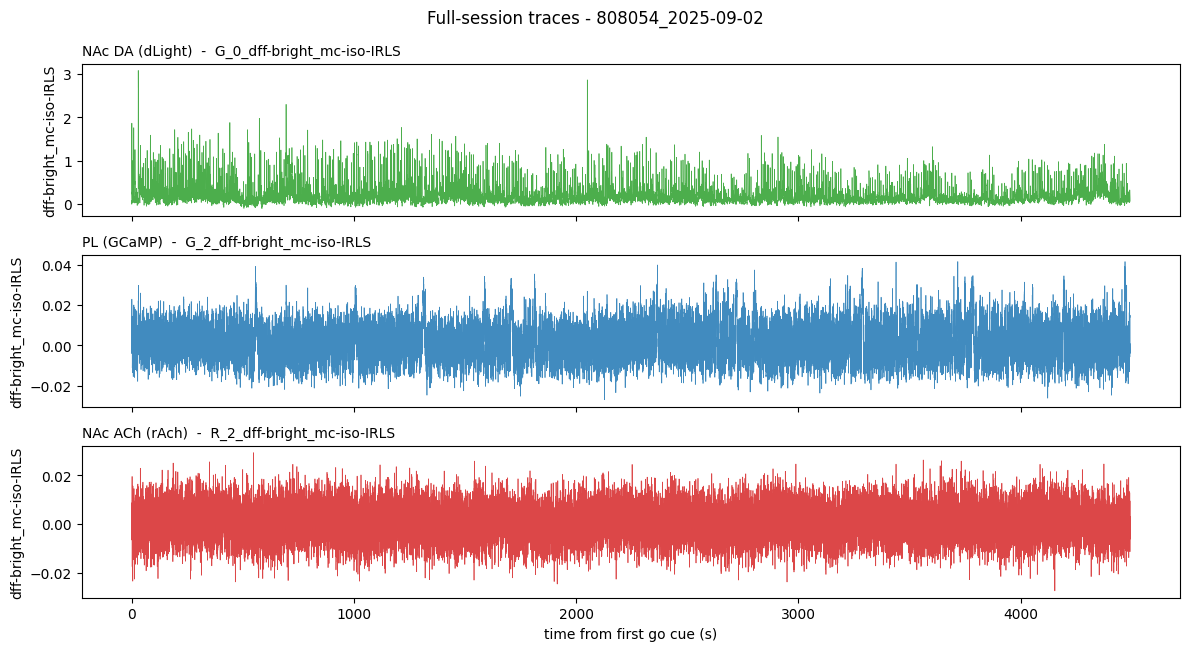

In [116]:
fig, axes = plt.subplots(len(examples), 1, sharex=True, figsize=(12, 2.2 * len(examples)))
for ax, ex in zip(np.atleast_1d(axes), examples):
    t, y = get_trace(df_fip, ex["event"])
    ax.plot(t, y, color=ex["color"], lw=0.5, alpha=0.85)
    ax.set_ylabel(ex["variant"])
    ax.set_title("%s  -  %s" % (ex["label"], ex["event"]), loc="left", fontsize=10)
np.atleast_1d(axes)[-1].set_xlabel("time from first go cue (s)")
fig.suptitle("Full-session traces - %s" % nwb.session_id)
fig.tight_layout()
plt.show()

### 60-second window with go cues

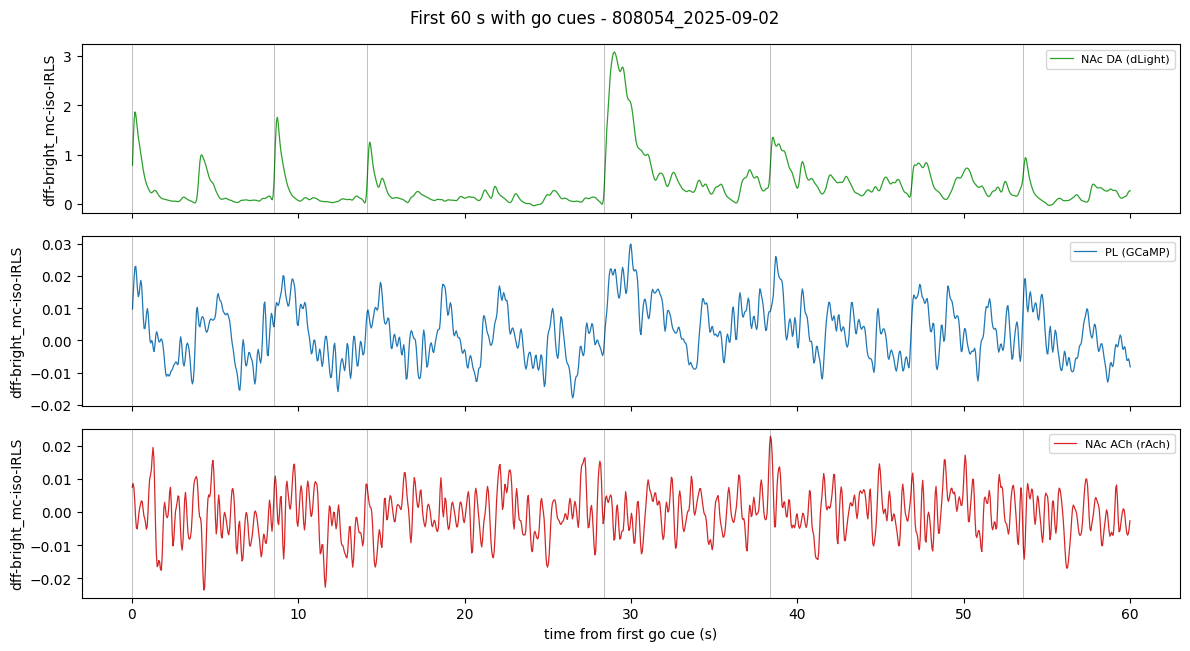

In [117]:
WINDOW = (0, 60)  # seconds from first go cue
cues = None
if cue_col is not None:  # cue_col detected in section 6
    cues = df_trials[cue_col]
    cues = cues[(cues >= WINDOW[0]) & (cues <= WINDOW[1])].to_numpy()

fig, axes = plt.subplots(len(examples), 1, sharex=True, figsize=(12, 2.2 * len(examples)))
for ax, ex in zip(np.atleast_1d(axes), examples):
    t, y = get_trace(df_fip, ex["event"])
    m = (t >= WINDOW[0]) & (t <= WINDOW[1])
    ax.plot(t[m], y[m], color=ex["color"], lw=0.9, label=ex["label"])
    if cues is not None:
        for c in cues:
            ax.axvline(c, color="k", lw=0.5, alpha=0.35)
    ax.set_ylabel(ex["variant"])
    ax.legend(loc="upper right", fontsize=8)
np.atleast_1d(axes)[-1].set_xlabel("time from first go cue (s)")
fig.suptitle("First %d s with go cues - %s" % (WINDOW[1], nwb.session_id))
fig.tight_layout()
plt.show()

### Peri-go-cue averages (native dff)

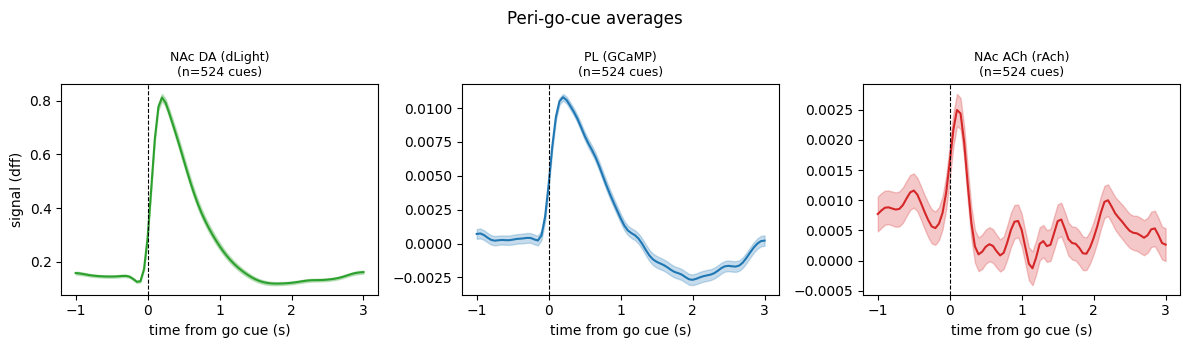

In [118]:
fig, axes = plt.subplots(1, len(examples), figsize=(4 * len(examples), 3.5))
for ax, ex in zip(np.atleast_1d(axes), examples):
    etr = peri_event(*get_trace(df_fip, ex["event"]), go_cues, t_before=1.0, t_after=3.0)
    agg = etr.groupby("time")["data"].agg(["mean", "sem"]).reset_index()
    ax.plot(agg["time"], agg["mean"], color=ex["color"])
    ax.fill_between(agg["time"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                    color=ex["color"], alpha=0.25)
    ax.axvline(0, color="k", lw=0.8, ls="--")
    ax.set_title("%s\n(n=%d cues)" % (ex["label"], etr["event_number"].nunique()), fontsize=9)
    ax.set_xlabel("time from go cue (s)")
np.atleast_1d(axes)[0].set_ylabel("signal (dff)")
fig.suptitle("Peri-go-cue averages")
fig.tight_layout()
plt.show()

### Z-scored motion energy & movement onsets

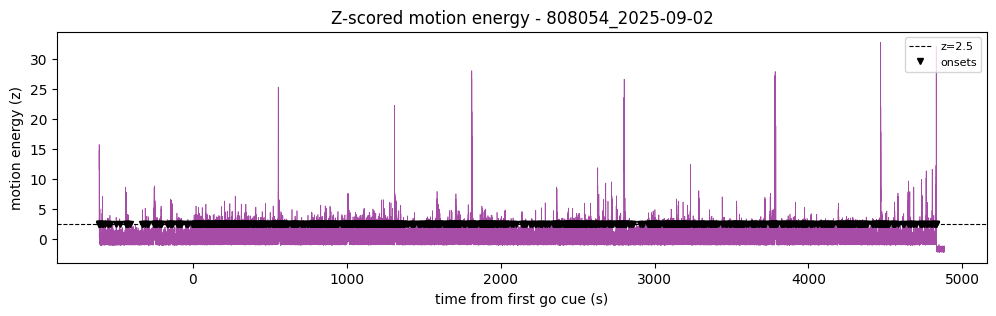

In [119]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t_me, me_z, color="purple", lw=0.5, alpha=0.7)
ax.axhline(Z_THRESH, color="k", ls="--", lw=0.8, label="z=%.1f" % Z_THRESH)
ax.plot(me_onset_times, np.full(len(me_onset_times), Z_THRESH), "v", color="k", ms=4,
        label="onsets")
ax.set_xlabel("time from first go cue (s)")
ax.set_ylabel("motion energy (z)")
ax.set_title("Z-scored motion energy - %s" % nwb.session_id)
ax.legend(loc="upper right", fontsize=8)
plt.show()

### FIP aligned to motion-energy onsets

Does each neuromodulator move with gross body movement?

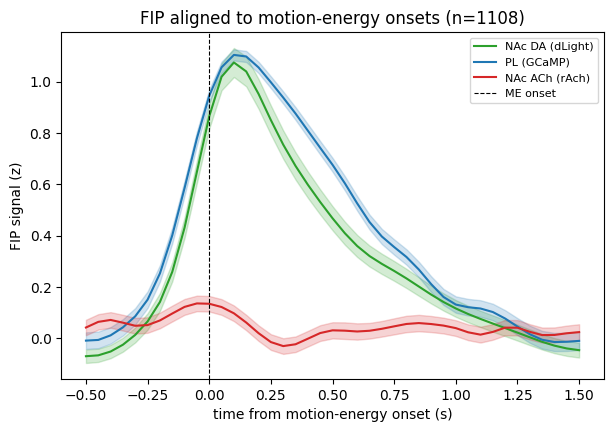

In [120]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for ex in examples:
    t, y = get_trace(df_fip, ex["event"])
    etr = peri_event(t, zscore(y), me_onset_times, t_before=0.5, t_after=1.5, censor=False)
    agg = etr.groupby("time")["data"].agg(["mean", "sem"]).reset_index()
    ax.plot(agg["time"], agg["mean"], color=ex["color"], label=ex["label"])
    ax.fill_between(agg["time"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                    color=ex["color"], alpha=0.2)
ax.axvline(0, color="k", lw=0.8, ls="--", label="ME onset")
ax.set_xlabel("time from motion-energy onset (s)")
ax.set_ylabel("FIP signal (z)")
ax.set_title("FIP aligned to motion-energy onsets (n=%d)" % len(me_onset_times))
ax.legend(fontsize=8)
plt.show()

### Motion energy aligned to each signal's transients

Reverse direction: a pre-transient rise in ME means movement tends to precede that signal.

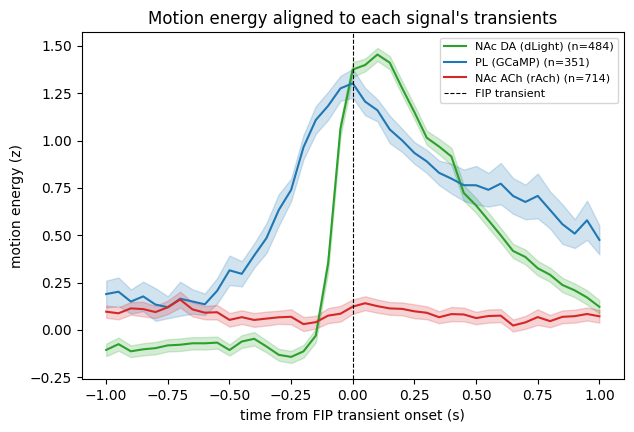

In [121]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for ex in examples:
    t, y = get_trace(df_fip, ex["event"])
    fip_onsets = threshold_onsets(t, y, z_thresh=2.0, refractory=1.0, smooth=3)
    etr = peri_event(t_me, me_z, fip_onsets, t_before=1.0, t_after=1.0, censor=False)
    agg = etr.groupby("time")["data"].agg(["mean", "sem"]).reset_index()
    ax.plot(agg["time"], agg["mean"], color=ex["color"],
            label="%s (n=%d)" % (ex["label"], len(fip_onsets)))
    ax.fill_between(agg["time"], agg["mean"] - agg["sem"], agg["mean"] + agg["sem"],
                    color=ex["color"], alpha=0.2)
ax.axvline(0, color="k", lw=0.8, ls="--", label="FIP transient")
ax.set_xlabel("time from FIP transient onset (s)")
ax.set_ylabel("motion energy (z)")
ax.set_title("Motion energy aligned to each signal's transients")
ax.legend(fontsize=8)
plt.show()

### Cross-correlation: motion energy × FIP

Resample both onto a common 20 Hz grid over their overlap; peak-lag sign shows which leads (positive = motion energy leads FIP).

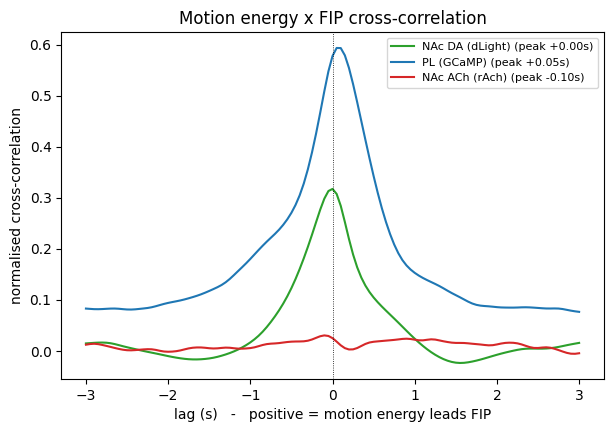

In [122]:
FS_XC = 20      # Hz, common resampling grid
MAXLAG = 3.0    # s

fig, ax = plt.subplots(figsize=(7, 4.5))
for ex in examples:
    t, y = get_trace(df_fip, ex["event"])
    finite = np.isfinite(t) & np.isfinite(y)
    t, y = t[finite], y[finite]
    lo = max(t.min(), t_me.min())
    hi = min(t.max(), t_me.max())
    grid = np.arange(lo, hi, 1.0 / FS_XC)
    fip_i = np.interp(grid, t, y)          # FIP on common grid
    me_i = np.interp(grid, t_me, me_z)     # ME (z) on common grid
    lags, c = norm_xcorr(fip_i, me_i, fs=FS_XC, maxlag=MAXLAG)
    peak = lags[int(np.argmax(c))]
    ax.plot(lags, c, color=ex["color"], label="%s (peak %+.2fs)" % (ex["label"], peak))
ax.axvline(0, color="k", lw=0.6, ls=":")
ax.set_xlabel("lag (s)   -   positive = motion energy leads FIP")
ax.set_ylabel("normalised cross-correlation")
ax.set_title("Motion energy x FIP cross-correlation")
ax.legend(fontsize=8)
plt.show()